# Smishing Triage — walkthrough

Separating **ham**, **commercial spam**, and **smishing** (phishing by SMS).

A binary ham-vs-spam filter puts a marketing blast and a credential-harvesting
message in the same class. For a user, one wastes three seconds and the other
costs them thousands of dollars. Separating them is the point of this project.

This notebook calls the modules in `src/` in the order the pipeline runs. It
contains no logic of its own — open the module named in each section to see how
a step works. `main.py` runs the same sequence headless.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # notebooks/ -> project root

import pandas as pd
import matplotlib.pyplot as plt

from src.config import CFG

print("labels      :", CFG.labels)
print("target class:", CFG.target_label, "— recall on this is the headline metric")
print("cost matrix :")
pd.DataFrame(CFG.cost_matrix(), index=CFG.labels, columns=CFG.labels)

labels      : ['ham', 'spam', 'smishing']
target class: smishing — recall on this is the headline metric
cost matrix :


,ham,spam,smishing
ham,0.0,1.0,2.0
spam,0.0,0.0,1.0
smishing,20.0,10.0,0.0


## 1. Data — `src/datasets.py`

Four corpora, four different formats, one schema. Each loader emits
`text` / `label` / `source`, so nothing downstream needs to know where a
message came from — except where that is used deliberately.

Only the Mendeley smishing set distinguishes commercial spam from smishing.
UCI has a single `spam` class that conflates the two, and the NUS corpus is
ham-only because it was collected from volunteers rather than a spam trap.

In [2]:
from src.datasets import load_all

raw = load_all()
pd.crosstab(raw["source"], raw["label"], margins=True)

  loaded uci: 5,574 rows


  loaded nus: 10,116 rows
  loaded mendeley_smishing: 5,971 rows
  loaded mendeley_balanced: 10,191 rows


label,ham,smishing,spam,All
source,,,,
mendeley_balanced,3397,3397,3397,10191
mendeley_smishing,4844,638,489,5971
nus,10116,0,0,10116
uci,4827,0,747,5574
All,23184,4035,4633,31852


### The corpora are built on each other

Deduplication is not housekeeping here — it is load-bearing. Mendeley's
smishing set is UCI plus re-labelling, and UCI absorbed part of the NUS corpus.
Split first and the same message lands in train and test.

In [3]:
from src.preprocess import deduplicate

deduped, conflicts = deduplicate(raw)
print(f"before : {len(raw):,}")
print(f"after  : {len(deduped):,}")
print(f"removed: {len(raw) - len(deduped):,}  ({1 - len(deduped)/len(raw):.0%})")

before : 31,852
after  : 18,257
removed: 13,595  (43%)


### The conflicts are the project's thesis, sitting in the data

Some messages carry *different labels in different corpora*. Almost all of them
are `uci=spam` versus `mendeley=smishing` on identical text — UCI calls a
credential-harvesting message "spam", Mendeley calls it "smishing".

`SOURCE_PRIORITY` in `preprocess.py` resolves them to the finer label. Had UCI
been ranked first, several hundred scams would have trained as marketing.

In [4]:
from src.preprocess import dedup_key

conflicts = conflicts.assign(_k=conflicts["text"].map(dedup_key))
print(f"{conflicts['_k'].nunique()} messages labelled inconsistently across corpora\n")

for key, group in list(conflicts.groupby("_k"))[:3]:
    print(" | ".join(f"{r.source}={r.label}" for r in group.itertuples()))
    print(f"   {group['text'].iloc[0][:95]}\n")

303 messages labelled inconsistently across corpora

mendeley_smishing=smishing | uci=spam | mendeley_balanced=smishing | mendeley_balanced=smishing | mendeley_smishing=smishing
   	07732584351 - Rodger Burns - MSG = We tried to call you re your reply to our sms for a free no

mendeley_balanced=smishing | mendeley_smishing=smishing | uci=spam | mendeley_smishing=smishing
   09066362231 URGENT! Your mobile No 07xxxxxxxxx won a Â£2,000 bonus caller prize on 02/06/03! th

mendeley_balanced=smishing | uci=spam | mendeley_balanced=smishing | uci=spam | mendeley_smishing=smishing | mendeley_balanced=smishing
   +123 congratulations - in this week's competition draw u have won the Â£1450 prize to claim jus



## 2. Preprocessing — `src/preprocess.py`

Normalise, deduplicate, split. Three decisions worth noticing:

**Placeholders, not deletion.** URLs, phone numbers and amounts become marker
tokens. Their *presence* is predictive even when the value is not.

**Two text columns.** `text_clean` feeds word features; raw `text` feeds
character features, because digits, case and punctuation are exactly what
obfuscated smishing abuses.

**Synthetic rows are barred from evaluation**, structurally — the LLM-generated
corpus is forced into the training split and cannot reach validation or test.
The NUS corpus is held out separately as the Singapore shift set.

In [5]:
from src.preprocess import normalise_text

for example in [
    "URGENT! Call 09061701461 now to claim your £2000 prize at http://bit.ly/x9",
    "Eh you reaching already? I order first ah",
]:
    print(f"raw   : {example}")
    print(f"clean : {normalise_text(example)}\n")

raw   : URGENT! Call 09061701461 now to claim your £2000 prize at http://bit.ly/x9
clean : urgent call phonetoken now to claim your moneytoken prize at urltoken

raw   : Eh you reaching already? I order first ah
clean : eh you reaching already i order first ah



In [6]:
from src.preprocess import build

splits = build()

=== loading ===
  loaded uci: 5,574 rows


  loaded nus: 10,116 rows
  loaded mendeley_smishing: 5,971 rows
  loaded mendeley_balanced: 10,191 rows
  total before deduplication: 31,852

=== deduplicating ===


  total after deduplication:  18,257
  label conflicts across corpora: 303 messages

=== normalising ===



=== splitting ===
  train       7,386  {'ham': 3374, 'smishing': 2329, 'spam': 1683}
  val           721  {'ham': 595, 'smishing': 66, 'spam': 60}
  test        1,202  {'ham': 993, 'smishing': 109, 'spam': 100}
  shift_sg    8,948  {'ham': 8948}


## 3. The model ladder — `src/train.py`

Four rungs, cheapest first. Each is scored on **validation**; the test set is
spent once, at the end, by the selected model only.

1. TF-IDF + Multinomial Naive Bayes — the floor
2. TF-IDF + Logistic Regression — linear baseline, readable coefficients
3. **Character n-grams + calibrated LinearSVC** — the obfuscation handler
4. Word + character features combined

Selection is on macro F1 with smishing recall as the tiebreak, applied
mechanically rather than by eye. The ladder is the deliverable as much as the
final model is: one model with a good number says nothing about whether a
simpler one would have done.

In [7]:
from src.train import run as train_run

leaderboard = train_run()

train 7,386  val 721  test 1,202
train class balance: {'ham': 3374, 'smishing': 2329, 'spam': 1683}


fitting nb_word_counts

--- nb_word_counts [val] ---
accuracy      0.9570
macro F1      0.8740
expected cost 0.1706  (lower is better)


smishing recall 0.8636   95% CI [0.779, 0.938]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        584     7         4
spam         3    49         8
smishing     1     8        57

top smishing misses:
  [spam] 	Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visi
  [spam] 	Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or Â£250 cash every wk. Txt VPOD to 81303 
  [spam] Mila, age23, blonde, new in UK. I look sex with UK guys. if u like fun with me. Text MTALK to 69866.
  [spam] UR awarded a City Break and could WIN a Â£200 Summer Shopping spree every WK. Txt STORE to 88039.Ski
  [spam] UR awarded a City Break and could WIN a Â£200 Summer Shopping spree every WK. Txt STORE to 88039 . S

fitting logreg_word_tfidf



--- logreg_word_tfidf [val] ---
accuracy      0.9695
macro F1      0.9019
expected cost 0.1026  (lower is better)


smishing recall 0.9091   95% CI [0.835, 0.972]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        590     4         1
spam         3    49         8
smishing     0     6        60

top smishing misses:
  [spam] 	Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visi
  [spam] 	Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or Â£250 cash every wk. Txt VPOD to 81303 
  [spam] Our records indicate u maybe entitled to 5000 pounds in compensation for the Accident you had. To cl
  [spam] UR awarded a City Break and could WIN a Â£200 Summer Shopping spree every WK. Txt STORE to 88039 . S
  [spam] 	We tried to contact you re your reply to our offer of a Video Phone 750 anytime any network mins Ha

fitting svm_char_tfidf



--- svm_char_tfidf [val] ---
accuracy      0.9792
macro F1      0.9298
expected cost 0.0527  (lower is better)


...

smishing recall 0.9091   95% CI [0.835, 0.972]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        592     3         0
spam         3    50         7
smishing     0     6        60

top smishing misses:
  [spam] 	Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visi
  [spam] 	Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or Â£250 cash every wk. Txt VPOD to 81303 
  [spam] Our records indicate u maybe entitled to 5000 pounds in compensation for the Accident you had. To cl
  [spam] 	We tried to contact you re your reply to our offer of a Video Phone 750 anytime any network mins Ha
  [spam] UR awarded a City Break and could WIN a Â£200 Summer Shopping spree every WK. Txt STORE to 88039 . S

VALIDATION LEADERBOARD
            model  accuracy  macro_f1  expected_cost  smishing_recall
   svm_char_tfidf    0.9792    0.9298         0.0527           0.9545
 logreg_word_char    0.9736    0.9125       


--- svm_char_tfidf [test] ---
accuracy      0.9784
macro F1      0.9234
expected cost 0.0557  (lower is better)


smishing recall 0.9541   95% CI [0.911, 0.990]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        992     0         1
spam         5    80        15
smishing     0     5       104

SINGAPORE SHIFT SET (NUS, ham only, n=8,948)


false alarm rate on local ham: 0.0022
ham         8928
spam          14
smishing       6



saved model to D:\Jon\Uni\BC3415\Project\Indiv\artifacts\model.joblib


### Reading the confusion matrix

Ham is near-perfect. Almost all remaining error sits on the **spam↔smishing**
boundary — which is the interesting part, because that boundary is what this
project exists to draw.

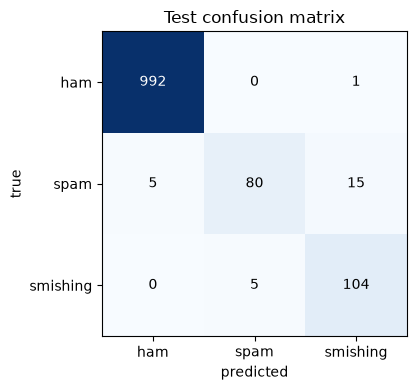

In [8]:
cm = pd.read_csv(CFG.reports_dir / "confusion_test.csv", index_col=0)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(cm.columns)), cm.columns)
ax.set_yticks(range(len(cm.index)), cm.index)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Test confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm.values[i, j]
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.values.max() / 2 else "black")
plt.tight_layout(); plt.show()

## 4. Is the synthetic augmentation earning its place? — `src/ablation.py`

Most training smishing examples are LLM-generated, which raises a question the
headline metric cannot answer: is the model learning smishing, or the
generator's style?

The comparison runs on **validation and the Singapore shift set only** — both
real messages. Spending the test set to choose an augmentation setting would be
exactly the leak the evaluation design exists to prevent.

In [9]:
from src.ablation import run as ablation_run

ablation = ablation_run()


real_only: 4,084 rows  {'ham': 3374, 'smishing': 371, 'spam': 339}



--- svm_char_tfidf / real_only [val] ---
accuracy      0.9612
macro F1      0.8652
expected cost 0.1540  (lower is better)


smishing recall 0.8636   95% CI [0.776, 0.940]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        595     0         0
spam         8    41        11
smishing     1     8        57


SG false alarm rate: 0.0023

real_plus_synthetic: 7,386 rows  {'ham': 3374, 'smishing': 2329, 'spam': 1683}



--- svm_char_tfidf / real_plus_synthetic [val] ---
accuracy      0.9792
macro F1      0.9298
expected cost 0.0527  (lower is better)


smishing recall 0.9545   95% CI [0.899, 1.000]

confusion matrix
predicted  ham  spam  smishing
true                          
ham        594     1         0
spam         4    49         7
smishing     0     3        63


SG false alarm rate: 0.0022

ABLATION — svm_char_tfidf, validation split
          condition  train_rows  accuracy  macro_f1  smishing_recall  expected_cost  sg_false_alarm_rate
          real_only        4084    0.9612    0.8652           0.8636         0.1540               0.0023
real_plus_synthetic        7386    0.9792    0.9298           0.9545         0.0527               0.0022

synthetic augmentation helps: smishing recall +0.0909 on validation


## 5. Serving — `src/predict.py`

`predict()` is the entry point everything downstream uses: this notebook, the
OCR path, the Telegram bot. Nothing calling it needs to know which rung won.

In [10]:
from src.predict import predict

for message in [
    "Eh you reaching already? I order first ah",
    "WIN a FREE iPhone! Txt WIN to 85233 now. T and Cs apply",
    "Your DBS account is suspended. Verify at http://dbs-secure.co/login",
]:
    r = predict(message)
    print(f"{message[:58]:60} -> {r.label:9} {r.confidence:.0%}")

Eh you reaching already? I order first ah                    -> ham       99%


WIN a FREE iPhone! Txt WIN to 85233 now. T and Cs apply      -> spam      98%
Your DBS account is suspended. Verify at http://dbs-secure   -> smishing  99%


### The screenshot path — `src/ocr.py`

Users forward screenshots far more readily than they retype a message. OCR
errors land *upstream* of the classifier, so a misread character becomes a
feature the model never saw in training — a genuine weakness, and one the
writeup should name rather than hide.

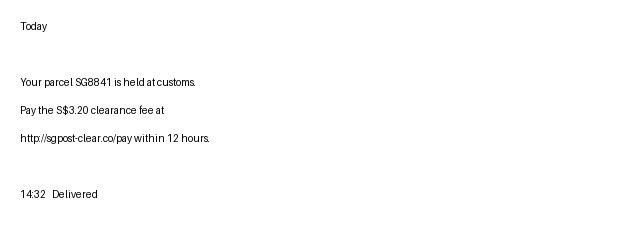


OCR read: 'Your parcel 9G8841 is held at customs. Pay the S$3.20 clearance fee at http://sgpost-clear.co/pay within 12 hours.'

⚠️ Likely scam (96%)
Flagged on: 'http://sgpost-clear.co/pay', 'customs.', 'hours.', 'Your'


In [11]:
from PIL import Image, ImageDraw
from src import ocr

# A mock screenshot, including the UI furniture a real one carries.
img = Image.new("RGB", (620, 250), "white")
draw = ImageDraw.Draw(img)
for i, line in enumerate([
    "Today", "",
    "Your parcel SG8841 is held at customs.",
    "Pay the S$3.20 clearance fee at",
    "http://sgpost-clear.co/pay within 12 hours.",
    "", "14:32   Delivered",
]):
    draw.text((20, 20 + i * 28), line, fill="black")

path = CFG.reports_dir / "mock_screenshot.png"
img.save(path)
display(img)

text = ocr.image_to_text(path)
print(f"\nOCR read: {text!r}")
print()
print(predict(text).describe())

### The LLM second stage — `src/scam_type.py`

Scam *type* labels (delivery, banking impersonation, job offer…) do not exist
as public labelled message data, so training a scam-type classifier would mean
inventing the labels — undermining the component the rubric weighs most.

Instead a zero-shot LLM names the type, and **only on messages the trained
model already flagged as smishing**. The gate lives inside `enrich()`, not in
the caller, so the second stage cannot accidentally run on everything — which
also keeps legitimate messages off the network.

It is explicitly unevaluated. No metric in this project depends on it.

In [12]:
from src import scam_type

message = "Your parcel is held at customs. Pay S$3.20 at http://sgpost-clear.co/pay"
prediction, scam = scam_type.enrich(message)

print(scam_type.describe(prediction, scam))
if scam is None:
    print("\n(enrichment off — set GEMINI_API_KEY; the classifier runs either way)")

⚠️ Likely scam (97%)
Flagged on: 'http://sgpost-clear.co/pay', 'Your', 'customs.'

(enrichment off — set GEMINI_API_KEY; the classifier runs either way)


## Summary

| | |
|---|---|
| Champion | character n-gram TF-IDF + calibrated LinearSVC |
| Headline | smishing recall, with a bootstrap confidence interval |
| Guardrail | false-alarm rate on real Singaporean ham |
| Front end | `python -m app.bot` — forward a message, get a verdict |

Known limitations are listed in `README.md`; the assignment framing and scope
boundaries are in `PROJECT_BRIEF.md`.